<a href="https://colab.research.google.com/github/sakilipoojithareddy-design/machine-learning/blob/main/Agriculture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os

zip_file = "/content/archive.zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("/content/crop_dataset")

print("ZIP extracted successfully!")
print(os.listdir("/content/crop_dataset"))

ZIP extracted successfully!
['state_soil_data.csv', 'crop_yield.csv', 'state_weather_data_1997_2020.csv']


In [ ]:
import os

dataset_path = "/content/crop_dataset"

print("Files inside the extracted folder:")
print(os.listdir(dataset_path))

Files inside the extracted folder:
['state_soil_data.csv', 'crop_yield.csv', 'state_weather_data_1997_2020.csv']


In [ ]:
import pandas as pd

dataset_path = "/content/crop_dataset"

# Load the three CSV files
crop_df = pd.read_csv(dataset_path + "/crop_yield.csv")
soil_df = pd.read_csv(dataset_path + "/state_soil_data.csv")
weather_df = pd.read_csv(dataset_path + "/state_weather_data_1997_2020.csv")

print("Crop Yield Dataset:", crop_df.shape)
print("Soil Dataset:", soil_df.shape)
print("Weather Dataset:", weather_df.shape)

#Check column names

print("\nCrop Yield Columns:")
print(crop_df.columns.tolist())

print("\nSoil Columns:")
print(soil_df.columns.tolist())

print("\nWeather Columns:")
print(weather_df.columns.tolist())

Crop Yield Dataset: (19689, 9)
Soil Dataset: (30, 5)
Weather Dataset: (720, 5)

Crop Yield Columns:
['crop', 'year', 'season', 'state', 'area', 'production', 'fertilizer', 'pesticide', 'yield']

Soil Columns:
['state', 'N', 'P', 'K', 'pH']

Weather Columns:
['state', 'year', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent']


In [ ]:
# ============================================================
# STEP 6: DATA CLEANING
# ============================================================

# Remove extra spaces from column names
crop_df.columns = crop_df.columns.str.strip()
soil_df.columns = soil_df.columns.str.strip()
weather_df.columns = weather_df.columns.str.strip()

# Remove extra spaces from text values
for col in crop_df.select_dtypes(include="object").columns:
    crop_df[col] = crop_df[col].astype(str).str.strip()

for col in soil_df.select_dtypes(include="object").columns:
    soil_df[col] = soil_df[col].astype(str).str.strip()

for col in weather_df.select_dtypes(include="object").columns:
    weather_df[col] = weather_df[col].astype(str).str.strip()

# Check missing values
print("MISSING VALUES")
print("\nCrop Yield Dataset:")
print(crop_df.isnull().sum())

print("\nSoil Dataset:")
print(soil_df.isnull().sum())

print("\nWeather Dataset:")
print(weather_df.isnull().sum())

# Check duplicate rows
print("\nDUPLICATE ROWS")
print("Crop Yield:", crop_df.duplicated().sum())
print("Soil:", soil_df.duplicated().sum())
print("Weather:", weather_df.duplicated().sum())

MISSING VALUES

Crop Yield Dataset:
crop          0
year          0
season        0
state         0
area          0
production    0
fertilizer    0
pesticide     0
yield         0
dtype: int64

Soil Dataset:
state    0
N        0
P        0
K        0
pH       0
dtype: int64

Weather Dataset:
state                   0
year                    0
avg_temp_c              0
total_rainfall_mm       0
avg_humidity_percent    0
dtype: int64

DUPLICATE ROWS
Crop Yield: 0
Soil: 0
Weather: 0


In [ ]:
# ============================================================
# STEP 7: MERGE THE THREE DATASETS
# ============================================================

# Merge crop yield data with soil data using STATE
merged_df = crop_df.merge(
    soil_df,
    on="state",
    how="left"
)

# Merge the weather data using STATE + YEAR
merged_df = merged_df.merge(
    weather_df,
    on=["state", "year"],
    how="left"
)

# Display results
print("=" * 60)
print("MERGED DATASET")
print("=" * 60)

print("\nOriginal crop dataset shape:")
print(crop_df.shape)

print("\nFinal merged dataset shape:")
print(merged_df.shape)

print("\nFinal columns:")
print(merged_df.columns.tolist())

print("\nFirst 5 rows:")
display(merged_df.head())

print("\nMissing values after merging:")
print(merged_df.isnull().sum().sum())

MERGED DATASET

Original crop dataset shape:
(19689, 9)

Final merged dataset shape:
(19689, 16)

Final columns:
['crop', 'year', 'season', 'state', 'area', 'production', 'fertilizer', 'pesticide', 'yield', 'N', 'P', 'K', 'pH', 'avg_temp_c', 'total_rainfall_mm', 'avg_humidity_percent']

First 5 rows:


,crop,year,season,state,area,production,fertilizer,pesticide,yield,N,P,K,pH,avg_temp_c,total_rainfall_mm,avg_humidity_percent
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,7024878.38,22882.34,0.796087,60,18,38,5.8,22.41,1468.92,70.71
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,631643.29,2057.47,0.710435,60,18,38,5.8,22.41,1468.92,70.71
2,Castor seed,1997,Kharif,Assam,796.0,22,75755.32,246.76,0.238333,60,18,38,5.8,22.41,1468.92,70.71
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,1870661.52,6093.36,5238.051739,60,18,38,5.8,22.41,1468.92,70.71
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,165500.63,539.09,0.420909,60,18,38,5.8,22.41,1468.92,70.71



Missing values after merging:
0


In [ ]:
# ============================================================
# STEP 8: TARGET VARIABLE ANALYSIS
# ============================================================

target = "yield"

print("=" * 60)
print("TARGET VARIABLE: YIELD")
print("=" * 60)

print("\nBasic statistics:")
print(merged_df[target].describe())

print("\nNumber of records:", merged_df[target].count())
print("Minimum yield:", merged_df[target].min())
print("Maximum yield:", merged_df[target].max())
print("Mean yield:", merged_df[target].mean())
print("Median yield:", merged_df[target].median())
print("Standard deviation:", merged_df[target].std())

TARGET VARIABLE: YIELD

Basic statistics:
count    19689.000000
mean        79.954009
std        878.306193
min          0.000000
25%          0.600000
50%          1.030000
75%          2.388889
max      21105.000000
Name: yield, dtype: float64

Number of records: 19689
Minimum yield: 0.0
Maximum yield: 21105.0
Mean yield: 79.95400913008669
Median yield: 1.03
Standard deviation: 878.3061926565939


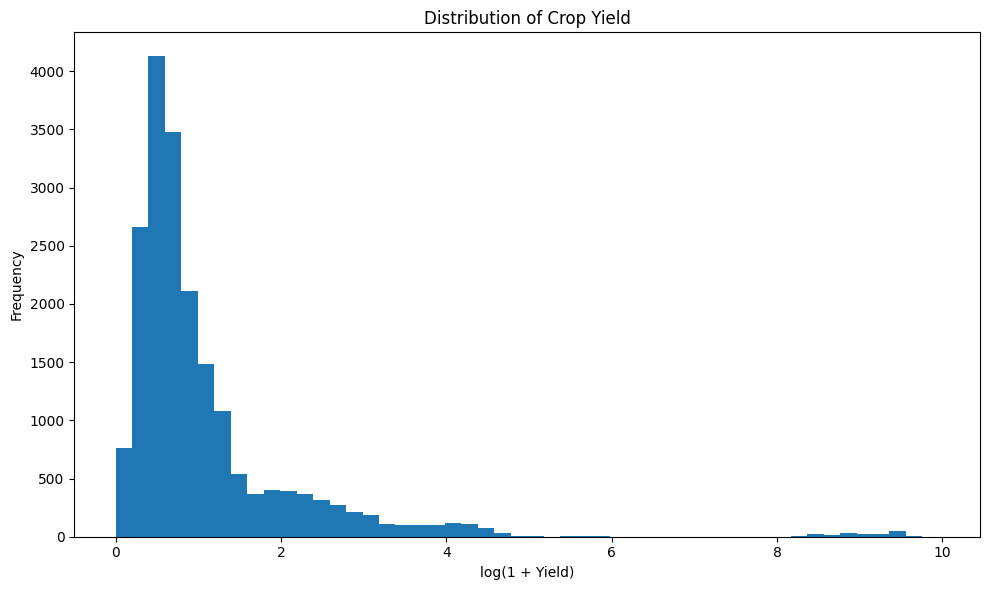

In [ ]:
# Yield distribution

plt.figure(figsize=(10, 6))

plt.hist(
    np.log1p(merged_df["yield"]),
    bins=50
)

plt.xlabel("log(1 + Yield)")
plt.ylabel("Frequency")
plt.title("Distribution of Crop Yield")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 9: CORRELATION ANALYSIS
# ============================================================

# Select numerical columns
numeric_df = merged_df.select_dtypes(include=np.number)

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

print("=" * 60)
print("CORRELATION WITH CROP YIELD")
print("=" * 60)

yield_correlation = correlation_matrix["yield"].sort_values(
    ascending=False
)

print(yield_correlation)

CORRELATION WITH CROP YIELD
yield                   1.000000
production              0.570809
avg_humidity_percent    0.063663
avg_temp_c              0.048464
K                       0.043650
P                       0.040731
total_rainfall_mm       0.005191
fertilizer              0.002862
year                    0.002539
area                    0.001858
pesticide               0.001782
N                       0.000567
pH                     -0.021938
Name: yield, dtype: float64


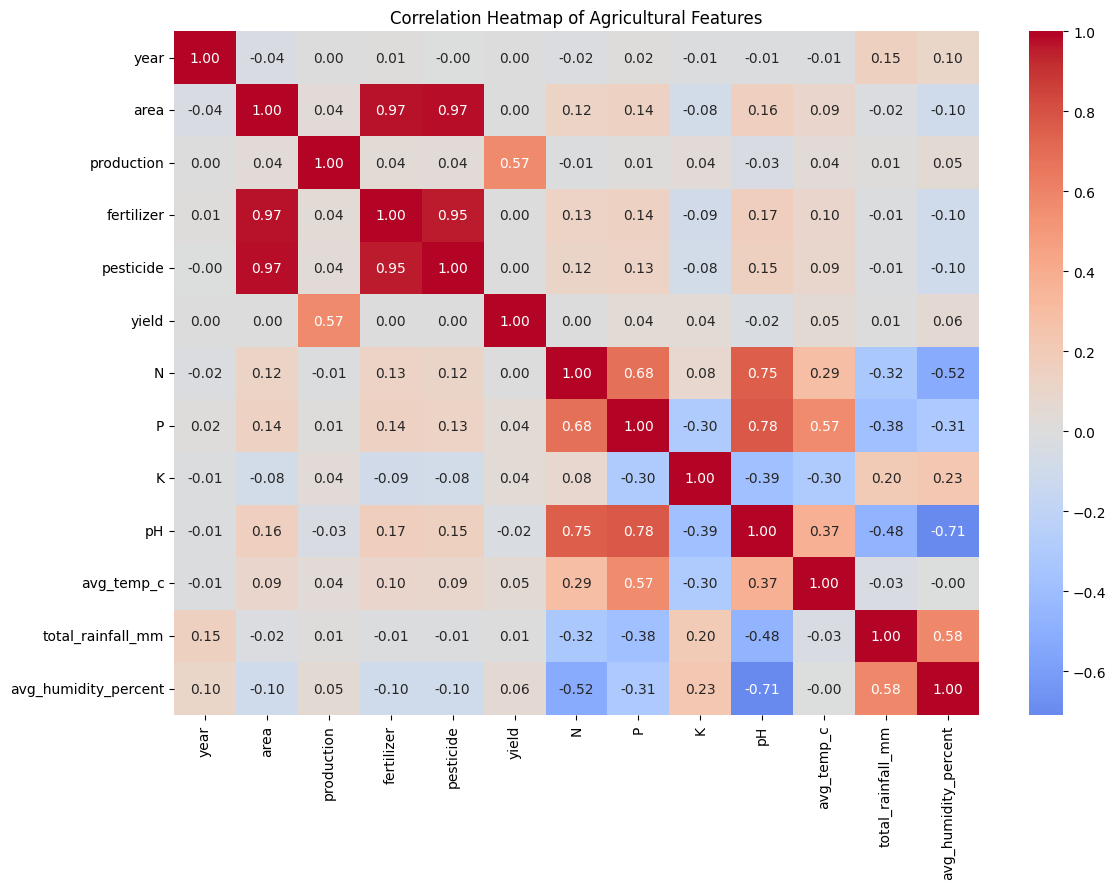

In [ ]:
# ============================================================
# CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Agricultural Features")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# STEP 10: FEATURE SELECTION
# ============================================================

target = "yield"

# Numerical features
numeric_features = [
    "area",
    "fertilizer",
    "pesticide",
    "N",
    "P",
    "K",
    "pH",
    "avg_temp_c",
    "rainfall_mm",
    "humidity_%"
]

# Categorical features
categorical_features = [
    "crop",
    "season",
    "state"
]

# Keep only columns that exist in our merged dataset
numeric_features = [
    col for col in numeric_features
    if col in merged_df.columns
]

categorical_features = [
    col for col in categorical_features
    if col in merged_df.columns
]

print("=" * 60)
print("FEATURES SELECTED FOR MODELING")
print("=" * 60)

print("\nNumerical Features:")
for feature in numeric_features:
    print("-", feature)

print("\nCategorical Features:")
for feature in categorical_features:
    print("-", feature)

print("\nTarget Variable:")
print("-", target)

print("\nExcluded Feature:")
print("- production")

FEATURES SELECTED FOR MODELING

Numerical Features:
- area
- fertilizer
- pesticide
- N
- P
- K
- pH
- avg_temp_c

Categorical Features:
- crop
- season
- state

Target Variable:
- yield

Excluded Feature:
- production


In [ ]:
# ============================================================
# STEP 11: CHRONOLOGICAL TRAIN / TEST SPLIT
# ============================================================

# Sort the data by year
merged_df = merged_df.sort_values(by="year").reset_index(drop=True)

# Training data: 1997 to 2015
train_df = merged_df[
    merged_df["year"] <= 2015
].copy()

# Testing data: 2016 to 2020
test_df = merged_df[
    merged_df["year"] >= 2016
].copy()

print("=" * 60)
print("CHRONOLOGICAL TRAIN / TEST SPLIT")
print("=" * 60)

print("\nTraining data:")
print("Rows:", len(train_df))
print("Years:", train_df["year"].min(), "to", train_df["year"].max())

print("\nTesting data:")
print("Rows:", len(test_df))
print("Years:", test_df["year"].min(), "to", test_df["year"].max())

print("\nTraining percentage:",
      round(len(train_df) / len(merged_df) * 100, 2), "%")

print("Testing percentage:",
      round(len(test_df) / len(merged_df) * 100, 2), "%")

CHRONOLOGICAL TRAIN / TEST SPLIT

Training data:
Rows: 15404
Years: 1997 to 2015

Testing data:
Rows: 4285
Years: 2016 to 2020

Training percentage: 78.24 %
Testing percentage: 21.76 %


In [ ]:
# ============================================================
# STEP 12: PREPROCESSING
# ============================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

# Separate input features (X) and target (y)
X_train = train_df[numeric_features + categorical_features]
y_train = train_df[target]

X_test = test_df[numeric_features + categorical_features]
y_test = test_df[target]

# Preprocessing:
# Numerical features -> StandardScaler
# Categorical features -> OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("=" * 60)
print("PREPROCESSING SETUP")
print("=" * 60)

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nTarget:")
print(target)

print("\nPreprocessing:")
print("Numerical features -> StandardScaler")
print("Categorical features -> OneHotEncoder")

PREPROCESSING SETUP

Numerical features:
['area', 'fertilizer', 'pesticide', 'N', 'P', 'K', 'pH', 'avg_temp_c']

Categorical features:
['crop', 'season', 'state']

Target:
yield

Preprocessing:
Numerical features -> StandardScaler
Categorical features -> OneHotEncoder


In [ ]:
# ============================================================
# STEP 13: RIDGE REGRESSION
# ============================================================

from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Create Ridge pipeline
ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge())
    ]
)

# Values of alpha to test
ridge_params = {
    "model__alpha": np.logspace(-3, 3, 20)
}

# Grid Search with 5-fold cross-validation
ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# Train Ridge model
ridge_search.fit(X_train, y_train)

# Best Ridge model
ridge_model = ridge_search.best_estimator_

print("=" * 60)
print("RIDGE REGRESSION")
print("=" * 60)

print("\nBest alpha:")
print(ridge_search.best_params_)

print("\nRidge model trained successfully!")

# Make predictions
ridge_pred = ridge_model.predict(X_test)

print("\nNumber of predictions:", len(ridge_pred))

print("\nFirst 10 predictions:")
print(ridge_pred[:10])

RIDGE REGRESSION

Best alpha:
{'model__alpha': np.float64(0.3359818286283781)}

Ridge model trained successfully!

Number of predictions: 4285

First 10 predictions:
[ 10.14872333 -19.57204344  -8.45059873  15.74982894  14.72121829
  11.90764483   0.34044239  -2.47085857   6.80499744  29.86367547]


In [ ]:
# ============================================================
# STEP 14: LASSO REGRESSION
# ============================================================

from sklearn.linear_model import Lasso

# Create Lasso pipeline
lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(max_iter=10000))
    ]
)

# Alpha values to test
lasso_params = {
    "model__alpha": np.logspace(-3, 2, 20)
}

# Grid Search with 5-fold cross-validation
lasso_search = GridSearchCV(
    estimator=lasso_pipeline,
    param_grid=lasso_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# Train Lasso model
lasso_search.fit(X_train, y_train)

# Best Lasso model
lasso_model = lasso_search.best_estimator_

print("=" * 60)
print("LASSO REGRESSION")
print("=" * 60)

print("\nBest alpha:")
print(lasso_search.best_params_)

print("\nLasso model trained successfully!")

# Make predictions
lasso_pred = lasso_model.predict(X_test)

print("\nNumber of predictions:", len(lasso_pred))

print("\nFirst 10 predictions:")
print(lasso_pred[:10])

LASSO REGRESSION

Best alpha:
{'model__alpha': np.float64(0.02069138081114789)}

Lasso model trained successfully!

Number of predictions: 4285

First 10 predictions:
[  7.64490618 -20.00421304  -9.30351762   9.45996982   7.67277684
   5.95761433  -1.95960769  -3.67150916   1.19590745  23.73761465]


In [ ]:
# ============================================================
# STEP 15: ELASTIC NET REGRESSION
# ============================================================

from sklearn.linear_model import ElasticNet

# Create Elastic Net pipeline
elastic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", ElasticNet(max_iter=10000))
    ]
)

# Alpha and L1 ratio values to test
elastic_params = {
    "model__alpha": np.logspace(-3, 2, 15),
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

# Grid Search with 5-fold cross-validation
elastic_search = GridSearchCV(
    estimator=elastic_pipeline,
    param_grid=elastic_params,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# Train Elastic Net model
elastic_search.fit(X_train, y_train)

# Best Elastic Net model
elastic_model = elastic_search.best_estimator_

print("=" * 60)
print("ELASTIC NET REGRESSION")
print("=" * 60)

print("\nBest parameters:")
print(elastic_search.best_params_)

print("\nElastic Net model trained successfully!")

# Make predictions
elastic_pred = elastic_model.predict(X_test)

print("\nNumber of predictions:", len(elastic_pred))

print("\nFirst 10 predictions:")
print(elastic_pred[:10])

ELASTIC NET REGRESSION

Best parameters:
{'model__alpha': np.float64(0.001), 'model__l1_ratio': 0.9}

Elastic Net model trained successfully!

Number of predictions: 4285

First 10 predictions:
[  8.41698807 -26.26002076 -13.96969402  14.01488366  13.84763822
  10.3489712   -4.5883893   -8.08509103   5.12848756  27.38093527]


In [ ]:
# ============================================================
# STEP 16: MODEL EVALUATION
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Function to calculate evaluation metrics
def evaluate_model(model_name, y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    mse = mean_squared_error(y_true, y_pred)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }


# Evaluate all three models
results = []

results.append(
    evaluate_model(
        "Ridge",
        y_test,
        ridge_pred
    )
)

results.append(
    evaluate_model(
        "Lasso",
        y_test,
        lasso_pred
    )
)

results.append(
    evaluate_model(
        "Elastic Net",
        y_test,
        elastic_pred
    )
)


# Create comparison table
results_df = pd.DataFrame(results)

print("=" * 70)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)

print(
    results_df.to_string(index=False)
)

MODEL PERFORMANCE COMPARISON
      Model       MAE          MSE       RMSE       R2
      Ridge 55.694729 89876.769269 299.794545 0.876014
      Lasso 54.693144 89612.002251 299.352639 0.876380
Elastic Net 55.868059 90593.073909 300.986833 0.875026


In [ ]:
# ============================================================
# STEP 16.5: FIND THE BEST MODEL
# ============================================================

best_model = results_df.loc[
    results_df["R2"].idxmax()
]

print("=" * 60)
print("BEST MODEL")
print("=" * 60)

print("Model:", best_model["Model"])
print("R²:", round(best_model["R2"], 4))
print("RMSE:", round(best_model["RMSE"], 4))
print("MAE:", round(best_model["MAE"], 4))

BEST MODEL
Model: Lasso
R²: 0.8764
RMSE: 299.3526
MAE: 54.6931


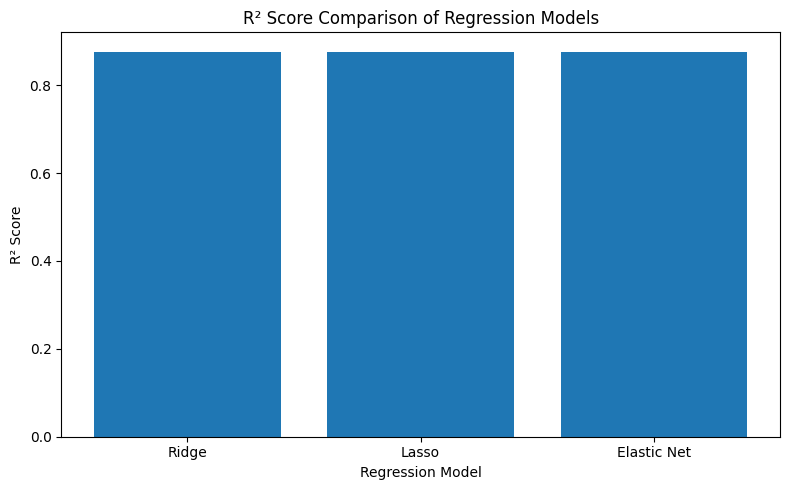

In [ ]:
# ============================================================
# STEP 17A: R² COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["R2"]
)

plt.xlabel("Regression Model")
plt.ylabel("R² Score")
plt.title("R² Score Comparison of Regression Models")

plt.tight_layout()
plt.show()

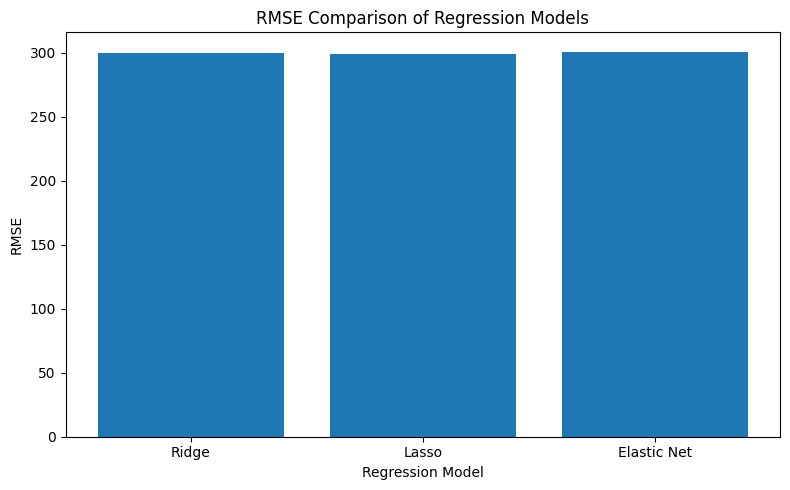

In [ ]:
# ============================================================
# STEP 17B: RMSE COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.xlabel("Regression Model")
plt.ylabel("RMSE")
plt.title("RMSE Comparison of Regression Models")

plt.tight_layout()
plt.show()

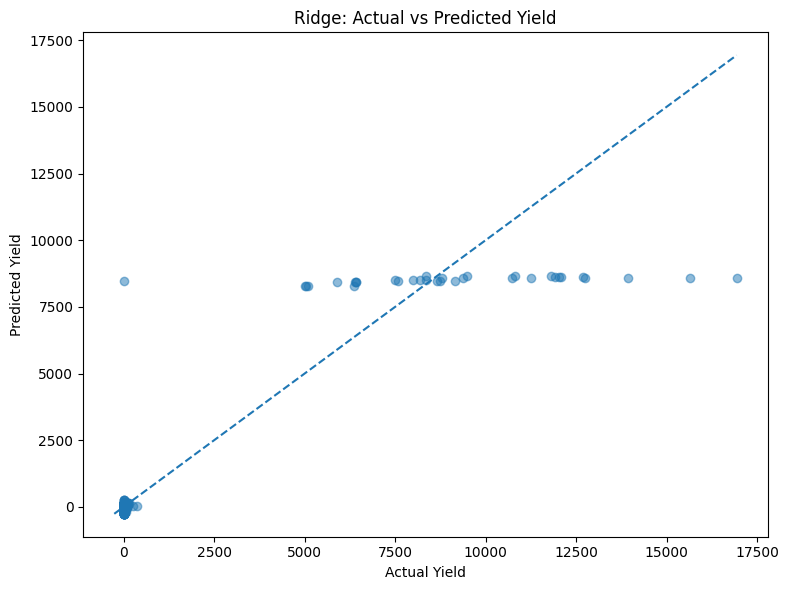

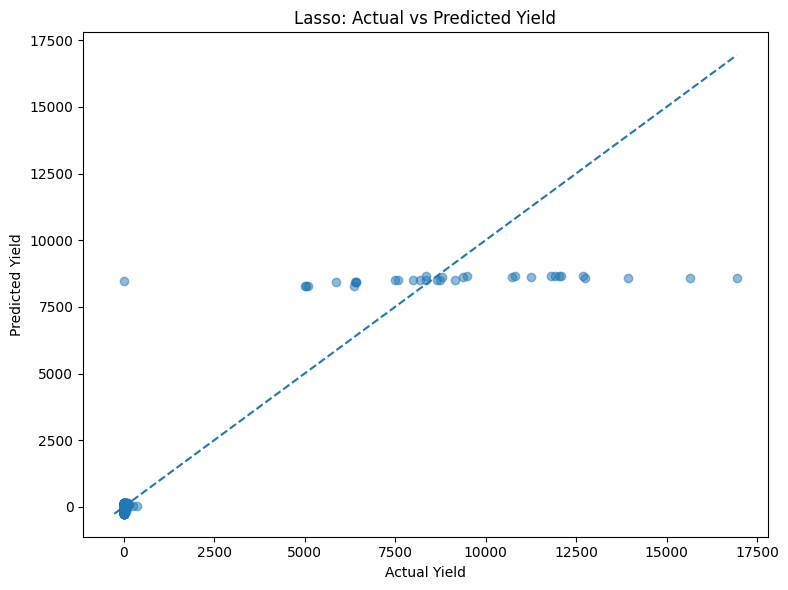

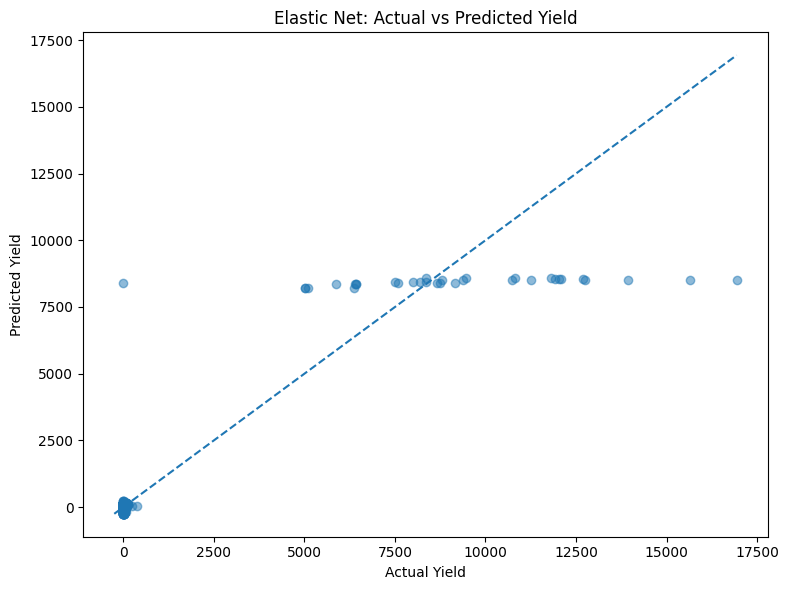

In [ ]:
# ============================================================
# STEP 18: ACTUAL VS PREDICTED YIELD
# ============================================================

predictions = {
    "Ridge": ridge_pred,
    "Lasso": lasso_pred,
    "Elastic Net": elastic_pred
}

for model_name, pred in predictions.items():

    plt.figure(figsize=(8, 6))

    # Actual vs predicted points
    plt.scatter(
        y_test,
        pred,
        alpha=0.5
    )

    # Perfect prediction line
    min_value = min(y_test.min(), pred.min())
    max_value = max(y_test.max(), pred.max())

    plt.plot(
        [min_value, max_value],
        [min_value, max_value],
        linestyle="--"
    )

    plt.xlabel("Actual Yield")
    plt.ylabel("Predicted Yield")
    plt.title(
        f"{model_name}: Actual vs Predicted Yield"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# STEP 19: LASSO FEATURE SELECTION
# ============================================================

# Get the preprocessing part of the trained Lasso pipeline
lasso_preprocessor = lasso_model.named_steps["preprocessor"]

# Get the trained Lasso regression model
lasso_regressor = lasso_model.named_steps["model"]

# Get the names of all encoded features
feature_names = lasso_preprocessor.get_feature_names_out()

# Get Lasso coefficients
coefficients = lasso_regressor.coef_

# Create a table
lasso_features = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Absolute coefficient for ranking
lasso_features["Absolute_Coefficient"] = (
    lasso_features["Coefficient"].abs()
)

# Sort by importance
lasso_features = lasso_features.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("=" * 70)
print("TOP FEATURES FROM LASSO")
print("=" * 70)

print(
    lasso_features.head(20).to_string(index=False)
)

# Count coefficients equal to zero
zero_features = (
    lasso_features["Coefficient"] == 0
).sum()

total_features = len(lasso_features)

print("\nTotal encoded features:", total_features)
print("Features with zero coefficient:", zero_features)

TOP FEATURES FROM LASSO
                Feature  Coefficient  Absolute_Coefficient
      cat__crop_Coconut  8518.372238           8518.372238
         cat__state_Goa  -284.153247            284.153247
      cat__state_Kerala  -174.190179            174.190179
cat__state_Chhattisgarh   -86.302894             86.302894
   cat__state_Telangana    72.370092             72.370092
   cat__state_Karnataka   -66.068071             66.068071
       cat__state_Assam   -56.565349             56.565349
 cat__season_Whole Year    43.959546             43.959546
                 num__P    40.166618             40.166618
    cat__crop_Coriander   -36.443249             36.443249
 cat__crop_Dry chillies   -29.687242             29.687242
 cat__state_West Bengal    25.901806             25.901806
    cat__crop_Sugarcane    25.468562             25.468562
         cat__crop_Rice    24.096970             24.096970
 cat__state_Maharashtra   -23.754432             23.754432
  cat__state_Tamil Nadu    23.18

In [ ]:
# ============================================================
# STEP 20: SAVE MODEL RESULTS
# ============================================================

# Save the model comparison table
results_df.to_csv(
    "/content/model_comparison_results.csv",
    index=False
)

print("=" * 60)
print("MODEL RESULTS SAVED")
print("=" * 60)

print("\nFile created:")
print("/content/model_comparison_results.csv")

print("\nFinal Model Comparison:")
display(results_df)

MODEL RESULTS SAVED

File created:
/content/model_comparison_results.csv

Final Model Comparison:


,Model,MAE,MSE,RMSE,R2
0,Ridge,55.694729,89876.769269,299.794545,0.876014
1,Lasso,54.693144,89612.002251,299.352639,0.876380
2,Elastic Net,55.868059,90593.073909,300.986833,0.875026


In [ ]:
# ============================================================
# STEP 21: FINAL PROJECT SUMMARY
# ============================================================

print("=" * 70)
print("CROP YIELD PREDICTION - FINAL PROJECT SUMMARY")
print("=" * 70)

print("\n1. DATASET")
print("Total records:", len(merged_df))
print("Total features used:", len(features))

print("\n2. TRAINING DATA")
print("Rows:", len(train_df))
print("Year range:", train_df["year"].min(), "-", train_df["year"].max())

print("\n3. TESTING DATA")
print("Rows:", len(test_df))
print("Year range:", test_df["year"].min(), "-", test_df["year"].max())

print("\n4. MODELS")
print("Ridge Regression")
print("Lasso Regression")
print("Elastic Net Regression")

print("\n5. MODEL RESULTS")
display(results_df.round(4))

print("\n6. BEST MODEL")

best_model_name = results_df.loc[
    results_df["R2"].idxmax(),
    "Model"
]

best_r2 = results_df["R2"].max()

print("Best Model:", best_model_name)
print("Best R²:", round(best_r2, 4))

print("\n7. TARGET VARIABLE")
print("Target:", target)

print("\n8. EXCLUDED FEATURE")
print("production")

print("\n" + "=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY!")
print("=" * 70)

CROP YIELD PREDICTION - FINAL PROJECT SUMMARY

1. DATASET
Total records: 19689


NameError: name 'features' is not defined